# 🌾 Crop Yield Prediction — Capstone Walkthrough

This notebook documents the end-to-end crop-yield prediction workflow used by the project. It is intentionally aligned with the repository's current training pipeline and reported evaluation files.

**Objective:** predict `yield_tonnes_ha` from agricultural, environmental, and farm-management variables.


## 1. Project Workflow

1. Load and validate the dataset  
2. Inspect distributions and missing values  
3. Prepare numeric and categorical features  
4. Compare Ridge, Random Forest, and Gradient Boosting  
5. Evaluate on a holdout test set and with 5-fold cross-validation  
6. Interpret the selected model with permutation importance  
7. Use the saved model in the Streamlit application


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
DATA_PATH = ROOT / 'data' / 'crop_yield_prediction.csv'
METRICS_PATH = ROOT / 'reports' / 'evaluation.json'
COMPARISON_PATH = ROOT / 'reports' / 'model_comparison.csv'
IMPORTANCE_PATH = ROOT / 'reports' / 'feature_importance.csv'

print('Repository root:', ROOT)


Repository root: /home/claude/crop_review/Crop Yield Prediction


In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())


Shape: (600, 11)


,crop,state,season,rainfall_mm,avg_temperature_c,soil_ph,soil_organic_matter_pct,nitrogen_kg_ha,farm_size_ha,irrigated,yield_tonnes_ha
0,sorghum,Kaduna,wet,751.8,30.2,6.51,2.25,69.3,2.11,0,2.77
1,maize,Taraba,dry,456.5,26.8,6.20,1.98,66.7,2.48,1,4.04
2,sorghum,Niger,wet,1101.2,26.7,6.52,4.05,58.0,4.16,0,3.61
3,sorghum,Kaduna,dry,362.6,30.1,6.64,3.47,53.2,2.70,0,2.83
4,cassava,Oyo,wet,1192.9,25.6,5.56,3.73,94.6,2.77,0,17.78


## 2. Data Quality Check


In [3]:
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'unique_values': df.nunique(),
})
display(quality)


,dtype,missing,unique_values
crop,str,0,5
state,str,0,8
season,str,0,2
rainfall_mm,float64,0,586
avg_temperature_c,float64,0,106
soil_ph,float64,0,222
soil_organic_matter_pct,float64,0,272
nitrogen_kg_ha,float64,0,454
farm_size_ha,float64,0,315
irrigated,int64,0,2


,yield_tonnes_ha
count,600.000000
mean,6.251850
std,4.899317
min,2.070000
25%,3.060000
50%,4.365000
75%,5.710000
max,20.060000


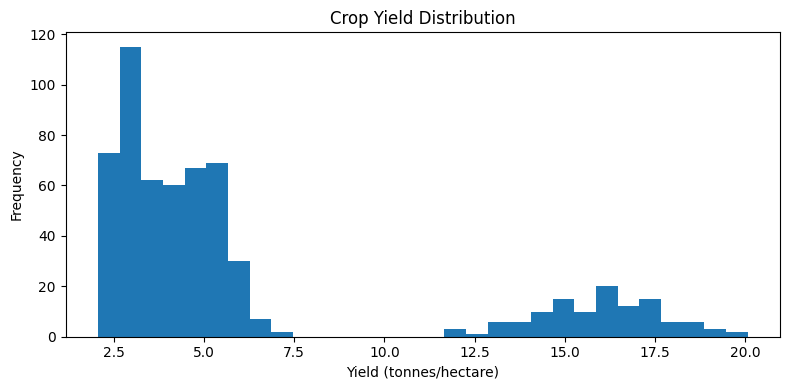

In [4]:
target = 'yield_tonnes_ha'
display(df[target].describe().to_frame('yield_tonnes_ha'))

plt.figure(figsize=(8, 4))
plt.hist(df[target], bins=30)
plt.xlabel('Yield (tonnes/hectare)')
plt.ylabel('Frequency')
plt.title('Crop Yield Distribution')
plt.tight_layout()
plt.show()


## 3. Crop-Level Exploration


,count,mean,median,std
crop,,,,
cassava,115,15.945478,15.970,1.752394
rice,120,5.428417,5.385,0.606859
maize,136,4.418750,4.390,0.513759
sorghum,125,3.088640,3.070,0.387359
soybean,104,2.682115,2.655,0.300897


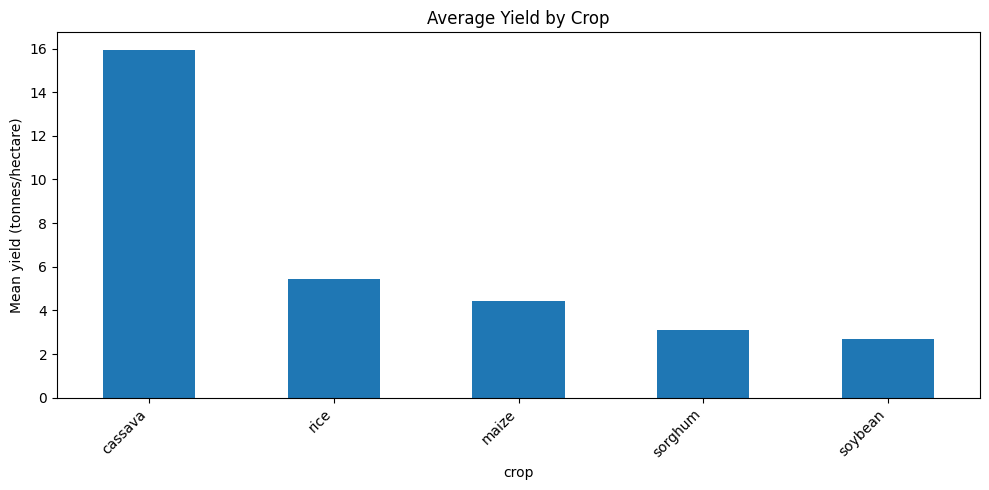

In [5]:
crop_summary = (df.groupby('crop')[target]
                .agg(['count', 'mean', 'median', 'std'])
                .sort_values('mean', ascending=False))
display(crop_summary)

plt.figure(figsize=(10, 5))
crop_summary['mean'].plot(kind='bar')
plt.ylabel('Mean yield (tonnes/hectare)')
plt.title('Average Yield by Crop')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 4. Model Comparison


,model,mae,rmse,r2
0,Gradient Boosting,0.289906,0.461917,0.989669
1,Random Forest,0.332564,0.548109,0.985454
2,Ridge Regression,0.433158,0.663614,0.978677


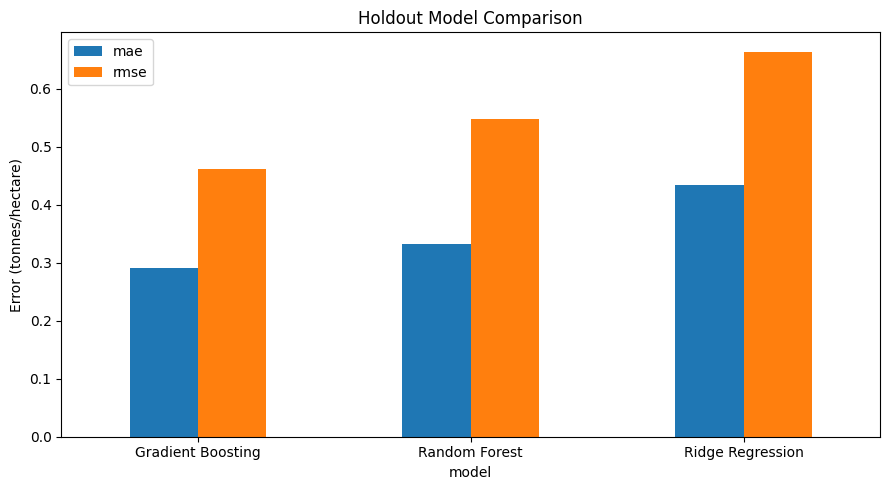

In [6]:
comparison = pd.read_csv(COMPARISON_PATH)
display(comparison)

comparison_plot = comparison.set_index('model')[['mae', 'rmse']]
comparison_plot.plot(kind='bar', figsize=(9, 5))
plt.ylabel('Error (tonnes/hectare)')
plt.title('Holdout Model Comparison')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Cross-Validation and Final Evaluation

The repository uses a fixed 80/20 holdout split for the reported test metrics and five-fold cross-validation to provide a more robust estimate of model stability.


In [7]:
metrics = json.loads(METRICS_PATH.read_text(encoding='utf-8'))
print('Selected model:', metrics['selected_model'])
print('Test metrics:')
display(pd.DataFrame([metrics['test_metrics']]))
print(f"5-fold CV RMSE: {metrics['five_fold_cv_rmse_mean']:.3f} ± {metrics['five_fold_cv_rmse_std']:.3f} tonnes/hectare")


Selected model: Gradient Boosting
Test metrics:


,mae,rmse,r2
0,0.289906,0.461917,0.989669


5-fold CV RMSE: 0.532 ± 0.056 tonnes/hectare


## 6. Feature Importance

Permutation importance estimates how much the model's MAE increases when each feature is shuffled. It indicates predictive reliance, not causality.


,feature,mae_increase,mae_increase_std
9,farm_size_ha,0.000069,0.000023
8,season,0.000101,0.000193
7,state,0.000775,0.000961
6,avg_temperature_c,0.003192,0.002472
5,soil_ph,0.023571,0.006128
4,rainfall_mm,0.028810,0.006720
3,irrigated,0.053184,0.007086
2,nitrogen_kg_ha,0.104134,0.016004
1,soil_organic_matter_pct,0.243048,0.038903
0,crop,3.696372,0.324443


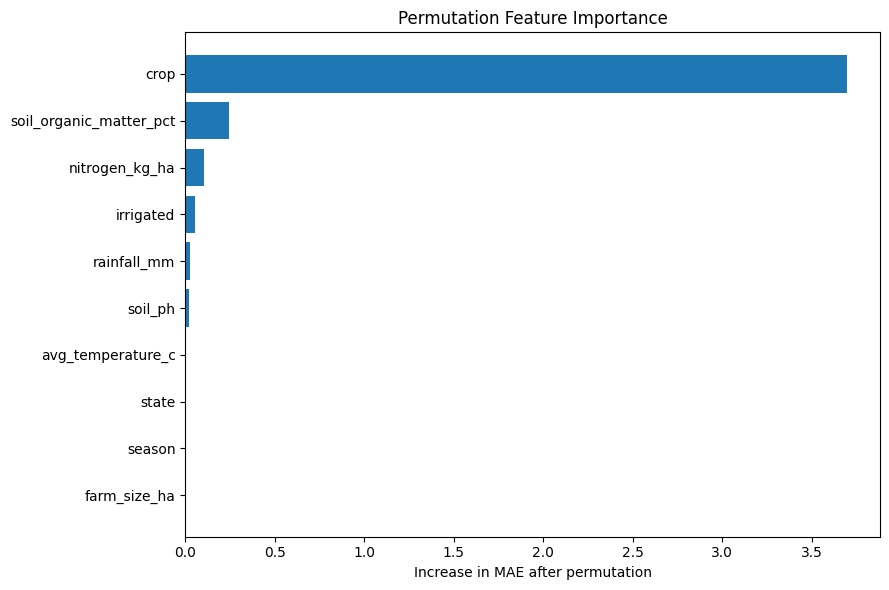

In [8]:
importance = pd.read_csv(IMPORTANCE_PATH).sort_values('mae_increase', ascending=True)
display(importance)

plt.figure(figsize=(9, 6))
plt.barh(importance['feature'], importance['mae_increase'])
plt.xlabel('Increase in MAE after permutation')
plt.title('Permutation Feature Importance')
plt.tight_layout()
plt.show()


## 7. Findings

- Gradient Boosting is the selected model in the current pipeline.
- The holdout evaluation reports strong predictive performance on the supplied dataset.
- Five-fold cross-validation is included to assess stability beyond a single split.
- Feature importance highlights which inputs the fitted model relies on most.
- **The dataset is synthetic** (generated by `src/generate_data.py` from a known formula), so the very high R² largely reflects the model recovering that formula rather than genuine real-world predictive skill. It should not be read as evidence of field performance.


## 8. Limitations and Next Steps

The dataset used here is synthetically generated, not collected from real farms, so results describe how well the model recovers the generating formula rather than real agronomic relationships. It has not been independently validated against field measurements. Future work should replace it with a real, independently sourced dataset, then investigate leakage, geographic/seasonal generalization, repeated cross-validation, hyperparameter tuning, and independent external validation.


## 9. Running the Project

From the repository root:

```bash
python -m pip install -r requirements.txt
python -m pytest -q
python src/train.py --data data/crop_yield_prediction.csv
python -m streamlit run app.py
```
